# Projet 10 - Réaliser une application de recommandation de contenu

## Import des packages

In [96]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## Import des données

In [97]:
clicks = pd.read_csv("../news-portal-user-interactions-by-globocom/clicks_sample.csv")
metadata = pd.read_csv("../news-portal-user-interactions-by-globocom/articles_metadata.csv")

with open("../news-portal-user-interactions-by-globocom/articles_embeddings.pickle", "rb") as f:
    embeddings = pickle.load(f)

## Visualisation et nettoyage des données

### Etape 1 : Nettoyer et filtrer des features et produits

### Objectif: 
- identifier ma cible selon les critères demandés
- mis en place un processus clair et automatisé pour filtrer les features (variables / colonnes) et des produits (ligns) qui seront utilisés pour atteindre l'objectif de mon projet

### Recommandations : 

- Lister l’ensemble des features du fichier, quantitatives (numériques) ou qualitatives (catégorielles).
- Choisisser une cible (une feature ayant moins de 50% de valeurs présente) catégorielle sera très probablement plus simple à gérer qu’une quantitative dans ce projet.
- Supprimer les lignes (produits) n’ayant pas de valeur cible.
Séparer la cible du reste du dataset.
- Afficher les taux de remplissage des features du dataset.
- Sélectionner des features qui sont asser remplis (plus que 50%) et qui vous paraissent intéressantes pour effectuer la prédiction de votre cible.
- Supprimer les produits en double.
- Automatiser tout ce que vous aver fait jusqu’à maintenant en utilisant :
        - une fonction qui prend en input votre dataframe d’origine ;
        - les méthodes spécifiques aux dataframes pandas ;
        - accessoirement numpy si ce que vous vouler faire n’est pas directement ou simplement disponible via la librairie pandas.
 
### Points de vigilance :

Attention à ne pas conserver trop de features.
Bien prendre en compte votre objectif principal dans la sélection des features.
Bien définir ce qui est considéré comme un doublon.

In [98]:
clicks

,user_id,session_id,session_start,session_size,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,0,1506825423271737,1506825423000,2,157541,1506826828020,4,3,20,1,20,2
1,0,1506825423271737,1506825423000,2,68866,1506826858020,4,3,20,1,20,2
2,1,1506825426267738,1506825426000,2,235840,1506827017951,4,1,17,1,16,2
3,1,1506825426267738,1506825426000,2,96663,1506827047951,4,1,17,1,16,2
4,2,1506825435299739,1506825435000,2,119592,1506827090575,4,1,17,1,24,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1878,705,1506828968165442,1506828968000,2,119592,1506830912301,4,1,17,1,21,2
1879,705,1506828968165442,1506828968000,2,284847,1506830942301,4,1,17,1,21,2
1880,706,1506828979881443,1506828979000,3,108854,1506829027334,4,3,2,1,25,1
1881,706,1506828979881443,1506828979000,3,96663,1506829095732,4,3,2,1,25,1


In [99]:
metadata

,article_id,category_id,created_at_ts,publisher_id,words_count
0,0,0,1513144419000,0,168
1,1,1,1405341936000,0,189
2,2,1,1408667706000,0,250
3,3,1,1408468313000,0,230
4,4,1,1407071171000,0,162
...,...,...,...,...,...
364042,364042,460,1434034118000,0,144
364043,364043,460,1434148472000,0,463
364044,364044,460,1457974279000,0,177
364045,364045,460,1515964737000,0,126


In [100]:
print(clicks.shape)
print("--------")
print(clicks.dtypes)
print("--------")
print(clicks.describe)

(1883, 12)
--------
user_id                int64
session_id             int64
session_start          int64
session_size           int64
click_article_id       int64
click_timestamp        int64
click_environment      int64
click_deviceGroup      int64
click_os               int64
click_country          int64
click_region           int64
click_referrer_type    int64
dtype: object
--------
<bound method NDFrame.describe of       user_id        session_id  session_start  session_size  \
0           0  1506825423271737  1506825423000             2   
1           0  1506825423271737  1506825423000             2   
2           1  1506825426267738  1506825426000             2   
3           1  1506825426267738  1506825426000             2   
4           2  1506825435299739  1506825435000             2   
...       ...               ...            ...           ...   
1878      705  1506828968165442  1506828968000             2   
1879      705  1506828968165442  1506828968000             2   

In [101]:
print(type(embeddings))
print(len(embeddings))

<class 'numpy.ndarray'>
364047


In [102]:
numeric_cols_clicks = clicks.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_clicks = clicks.select_dtypes(exclude=['int64', 'float64']).columns

print(f"Nombre de variables quantitatives : {len(numeric_cols_clicks)}")
print(f"Variables quantitatives : {list(numeric_cols_clicks)}")
print(f"\nNombre de variables qualitatives : {len(categorical_cols_clicks)}")
print(f"Variables qualitatives : {list(categorical_cols_clicks)}")

Nombre de variables quantitatives : 12
Variables quantitatives : ['user_id', 'session_id', 'session_start', 'session_size', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']

Nombre de variables qualitatives : 0
Variables qualitatives : []


On a 12 variables pour clicks

In [103]:
numeric_cols_metadata = metadata.select_dtypes(include=['int64', 'float64']).columns
categorical_cols_metadata = metadata.select_dtypes(exclude=['int64', 'float64']).columns

print(f"Nombre de variables quantitatives : {len(numeric_cols_metadata)}")
print(f"Variables quantitatives : {list(numeric_cols_metadata)}")
print(f"\nNombre de variables qualitatives : {len(categorical_cols_metadata)}")
print(f"Variables qualitatives : {list(categorical_cols_metadata)}")

Nombre de variables quantitatives : 5
Variables quantitatives : ['article_id', 'category_id', 'created_at_ts', 'publisher_id', 'words_count']

Nombre de variables qualitatives : 0
Variables qualitatives : []


On a 5 variables pour metadata

### On visualise le nombre de valeurs manquantes

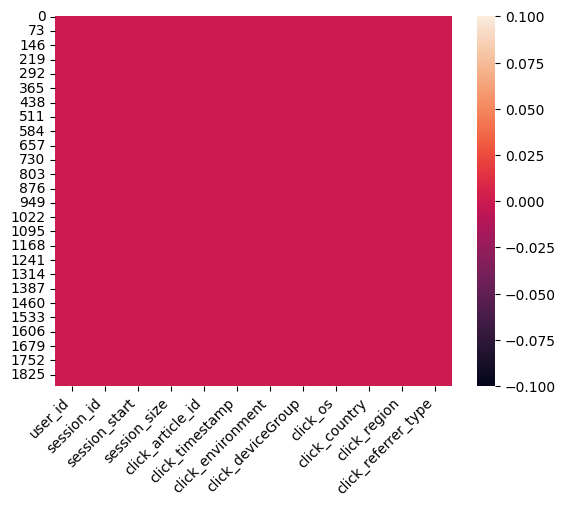

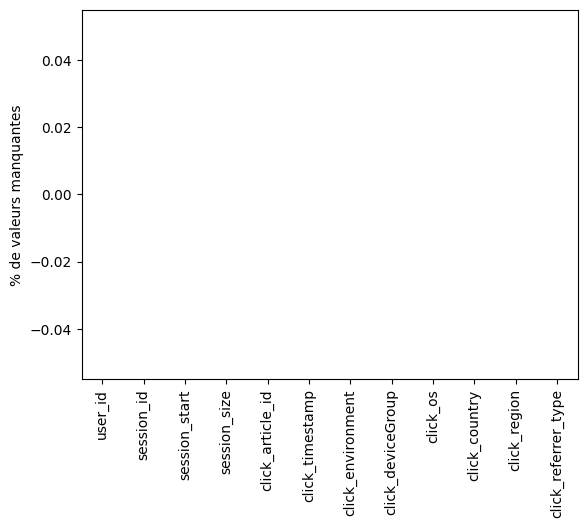

In [104]:
sns.heatmap(clicks.isna())
plt.xticks(rotation=45, ha='right')
plt.show()

missing_rate = clicks.isna().mean() * 100

missing_rate.sort_values(ascending=False).plot.bar()
plt.ylabel("% de valeurs manquantes")
plt.show()

Aucune valeur manquante pour clicks

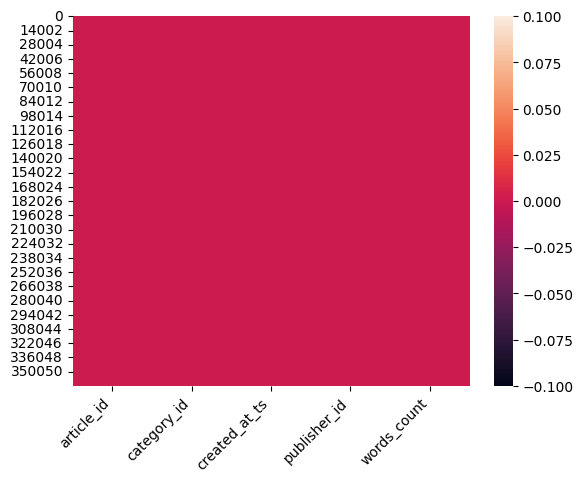

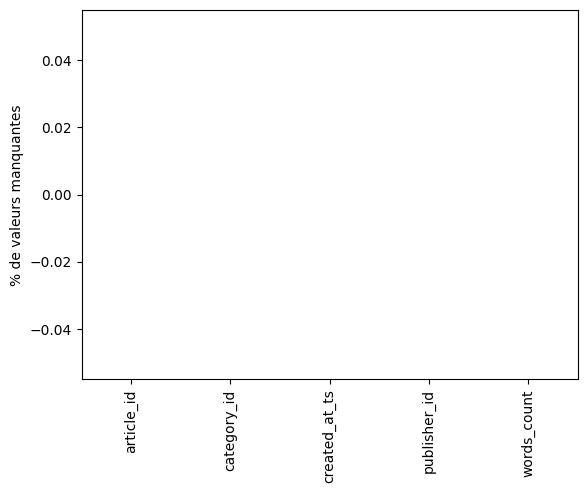

In [105]:
sns.heatmap(metadata.isna())
plt.xticks(rotation=45, ha='right')
plt.show()

missing_rate = metadata.isna().mean() * 100

missing_rate.sort_values(ascending=False).plot.bar()
plt.ylabel("% de valeurs manquantes")
plt.show()

Aucune valeur manquante pour metadata

### Analyse des distributions

Moyenne clics/user : 2.66
Médiane clics/user : 2.00
Max clics/user : 24


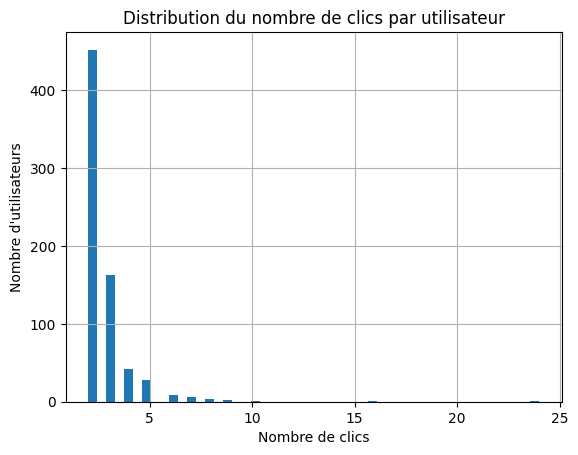

In [106]:
# Nombre de clics par utilisateur
clicks_per_user = clicks.groupby('user_id').size()
print(f"Moyenne clics/user : {clicks_per_user.mean():.2f}")
print(f"Médiane clics/user : {clicks_per_user.median():.2f}")
print(f"Max clics/user : {clicks_per_user.max()}")

# Distribution
clicks_per_user.hist(bins=50)
plt.title("Distribution du nombre de clics par utilisateur")
plt.xlabel("Nombre de clics")
plt.ylabel("Nombre d'utilisateurs")
plt.show()

Moyenne clics/article : 5.83
Médiane clics/article : 1.00
Max clics/article : 202


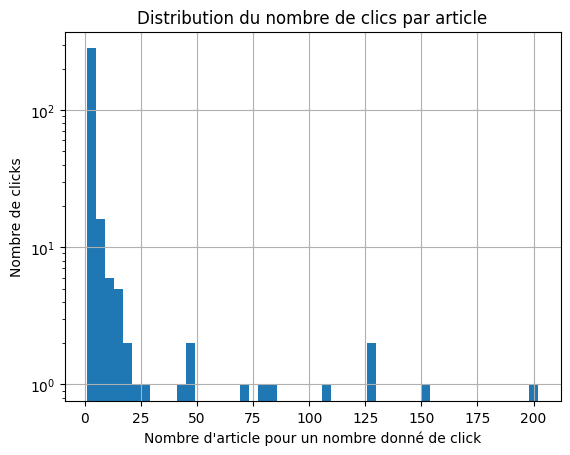

In [107]:
clicks_per_article = clicks.groupby("click_article_id").size()

print(f"Moyenne clics/article : {clicks_per_article.mean():.2f}")
print(f"Médiane clics/article : {clicks_per_article.median():.2f}")
print(f"Max clics/article : {clicks_per_article.max()}")

clicks_per_article.hist(bins=50)
plt.title("Distribution du nombre de clics par article")
plt.xlabel("Nombre d'article pour un nombre donné de click")
plt.ylabel("Nombre de clicks")
plt.yscale('log')
plt.show()

### Sparsité

**Définition mathématique** :

$$\text{Sparsité} = 1 - \frac{\text{nombre d'interactions observées}}{\text{nombre d'utilisateurs} \times \text{nombre d'articles}}$$


In [108]:
nombre_interactions = len(clicks)
nombre_interactions

1883

In [109]:
nombre_utilisateurs = clicks['user_id'].nunique()
nombre_utilisateurs

707

In [110]:
nombre_articles = metadata['article_id'].nunique()
nombre_articles

364047

In [111]:
sparsite = 1 - nombre_interactions / (nombre_utilisateurs * nombre_articles)
sparsite

0.9999926840041625

In [112]:
print(1 - sparsite)

7.315995837475775e-06


0.0007316 % des interactions possibles sont observées.

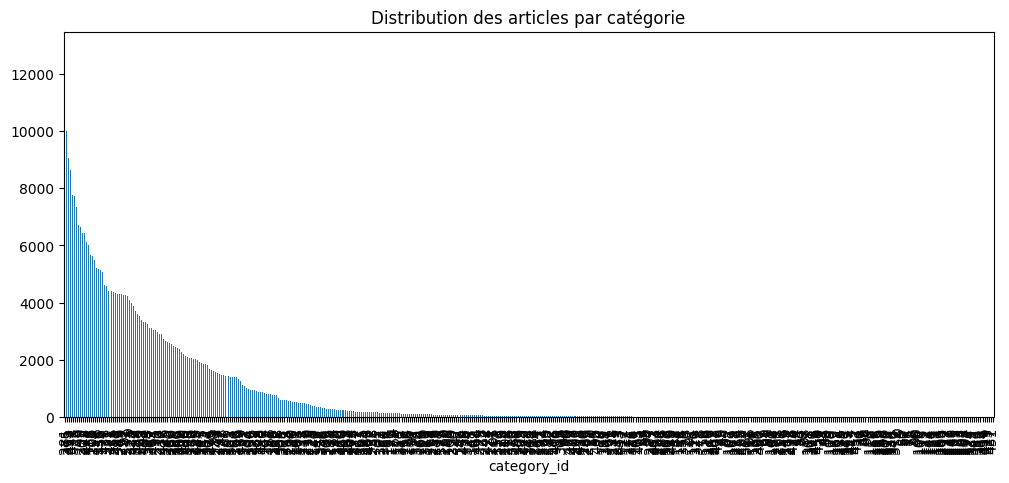

In [113]:
# Distribution des catégories
category_counts = metadata['category_id'].value_counts()
category_counts.plot(kind='bar', figsize=(12, 5))
plt.title("Distribution des articles par catégorie")
plt.show()

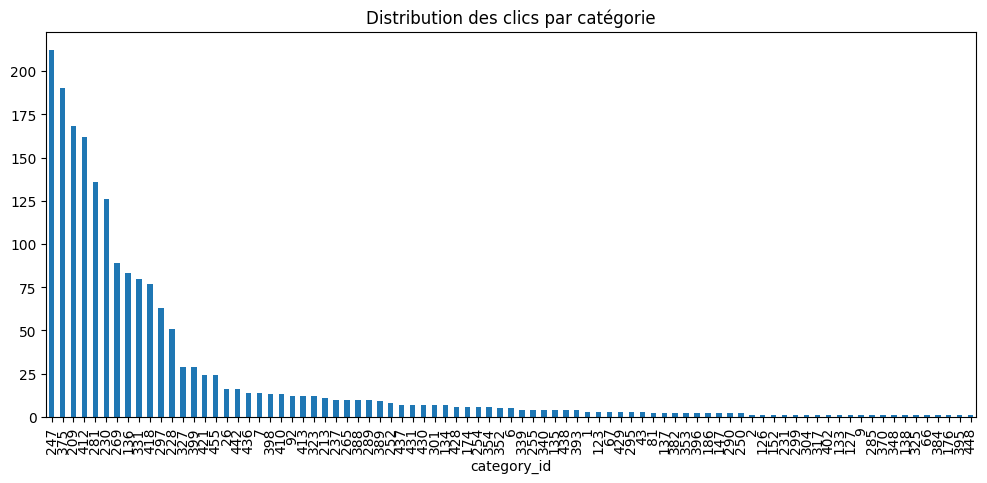

In [114]:
# Catégories les plus cliquées
clicks_with_meta = clicks.merge(metadata, left_on='click_article_id', right_on='article_id')
category_clicks = clicks_with_meta['category_id'].value_counts()
category_clicks.plot(kind='bar', figsize=(12, 5))
plt.title("Distribution des clics par catégorie")
plt.show()